# Fusion Model: ResNet-18, MobileNetV2, Efficient-B0

---
## Imports

In [2]:
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torch.cuda.amp import GradScaler, autocast

torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


## Configuration

In [7]:
DATASET_PATH = r"e:\LamMinhTri\Tai_Lieu_Hoc_Tap\2026_Semester 1\DAT301m\The_Emotion_Explorers\Mood-and-Attention-Monitoring-in-Online-Classrooms\dataset"

NUM_CLASSES = 7
BATCH_SIZE = 64
EPOCHS = 200
LR = 1e-3
IMAGE_SIZE = 96

CLASS_NAMES = ['anger','disgust','fear','happy','neutral','sad','surprise']

## Transformation

In [10]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

## Datasets & Loaders

In [4]:
train_dataset = datasets.ImageFolder(os.path.join(DATASET_PATH, "train"), transform=train_transform)
test_dataset = datasets.ImageFolder(os.path.join(DATASET_PATH, "test"), transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=4, pin_memory=True)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 9275
Test size: 8771


## Fusion Model


In [5]:
class FusionEmotionModel(nn.Module):
    def __init__(self, num_classes=7):
        super(FusionEmotionModel, self).__init__()
        
        # ResNet18
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.resnet.fc = nn.Identity()
        
        # MobileNetV2
        self.mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        self.mobilenet.classifier = nn.Identity()
        
        # EfficientNet-B0
        self.efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        self.efficientnet.classifier = nn.Identity()
        
        self.fusion = nn.Sequential(
            nn.Linear(512 + 1280 + 1280, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        f1 = self.resnet(x)
        f2 = self.mobilenet(x)
        f3 = self.efficientnet(x)
        
        fused = torch.cat([f1, f2, f3], dim=1)
        out = self.fusion(fused)
        return out

## Initialize Model

In [6]:
model = FusionEmotionModel(NUM_CLASSES).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scaler = GradScaler()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9116\1909483363.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


## Training & Validation

In [7]:
def train_one_epoch(model, loader):
    model.train()
    running_loss, correct = 0.0, 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels)
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = correct.double() / len(loader.dataset)
    
    return epoch_loss, epoch_acc.item()


def validate(model, loader):
    model.eval()
    running_loss, correct = 0.0, 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = correct.double() / len(loader.dataset)
    
    return epoch_loss, epoch_acc.item(), all_preds, all_labels

## Training Loop + Best Model Saving

In [8]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):
    start = time.time()
    
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc, preds, labels = validate(model, test_loader)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), "best_fusion_emotion_model.pth")
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} "
          f"Time: {time.time()-start:.2f}s")

# Save final model
torch.save(model.state_dict(), "final_fusion_emotion_model.pth")

print("Training Complete.")
print("Best Validation Accuracy:", best_acc)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9116\1871366510.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/200] Train Loss: 1.5236 | Train Acc: 0.3724 Val Loss: 1.4929 | Val Acc: 0.4022 Time: 43.79s
Epoch [2/200] Train Loss: 1.2562 | Train Acc: 0.4791 Val Loss: 1.3162 | Val Acc: 0.5202 Time: 37.79s
Epoch [3/200] Train Loss: 1.1829 | Train Acc: 0.5103 Val Loss: 1.1885 | Val Acc: 0.5397 Time: 37.82s
Epoch [4/200] Train Loss: 1.1470 | Train Acc: 0.5327 Val Loss: 1.2387 | Val Acc: 0.5453 Time: 37.60s
Epoch [5/200] Train Loss: 1.0975 | Train Acc: 0.5486 Val Loss: 1.1429 | Val Acc: 0.5901 Time: 37.54s
Epoch [6/200] Train Loss: 1.0592 | Train Acc: 0.5678 Val Loss: 1.2176 | Val Acc: 0.5367 Time: 37.48s
Epoch [7/200] Train Loss: 1.0516 | Train Acc: 0.5773 Val Loss: 1.3220 | Val Acc: 0.5840 Time: 37.36s
Epoch [8/200] Train Loss: 1.0282 | Train Acc: 0.5857 Val Loss: 1.1757 | Val Acc: 0.5851 Time: 38.38s
Epoch [9/200] Train Loss: 1.0210 | Train Acc: 0.5877 Val Loss: 1.0993 | Val Acc: 0.5941 Time: 38.66s
Epoch [10/200] Train Loss: 1.0014 | Train Acc: 0.5963 Val Loss: 1.2241 | Val Acc: 0.5600 Ti

## Training Curves

In [1]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure()
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

NameError: name 'plt' is not defined

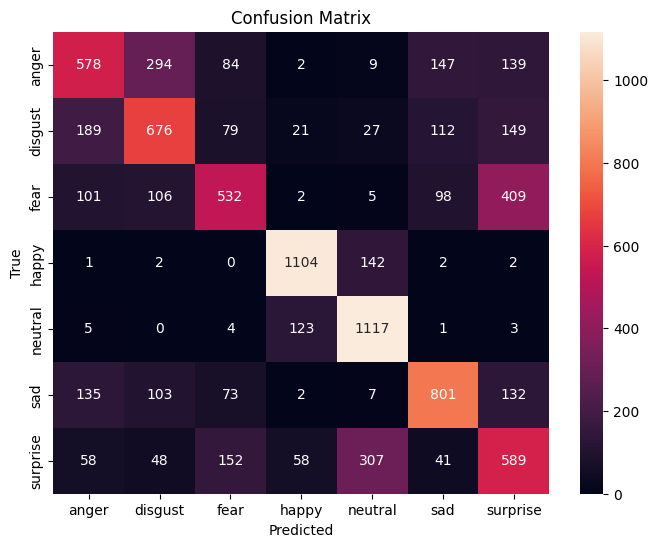

              precision    recall  f1-score   support

       anger       0.54      0.46      0.50      1253
     disgust       0.55      0.54      0.54      1253
        fear       0.58      0.42      0.49      1253
       happy       0.84      0.88      0.86      1253
     neutral       0.69      0.89      0.78      1253
         sad       0.67      0.64      0.65      1253
    surprise       0.41      0.47      0.44      1253

    accuracy                           0.62      8771
   macro avg       0.61      0.62      0.61      8771
weighted avg       0.61      0.62      0.61      8771



In [10]:
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()

print(classification_report(labels, preds, target_names=CLASS_NAMES))

In [3]:
def predict_image(model, image):
    model.eval()
    image = test_transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(image)
        probs = torch.softmax(output, dim=1)
        confidence, pred = torch.max(probs, 1)
    
    return CLASS_NAMES[pred.item()], confidence.item()

In [8]:
model = FusionEmotionModel(NUM_CLASSES).to(device)
model.load_state_dict(torch.load("best_fusion_emotion_model.pth"))
model.eval()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11468\2579379648.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_fusion_emotion_model

FusionEmotionModel(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True,

In [14]:
from PIL import Image

image_path = r"C:\Users\LENOVO\Downloads\360_F_48883681_3YSVqKeyIvDNGZ9t0A8ynIFaeo64sHDm.jpg"  # change to your image
image = Image.open(image_path).convert("RGB")

label, confidence = predict_image(model, image)

print("Predicted Emotion:", label)
print("Confidence:", round(confidence, 4))

Predicted Emotion: neutral
Confidence: 0.9988
